# Did cheaper subs sell more subs?

**Price elasticity of Twitch channel subscriptions from the 2021 local-pricing rollout.**

This notebook is the narrative walk-through of the analysis. Every number here is produced by
the pipeline (`make synth`, `python -m src.panel.pilot_build`, `python -m src.estimate.final`,
`python -m src.diagnostics.run`) — the notebook only reads saved outputs and re-renders the story.

**Design in one paragraph.** Twitch cut Tier-1 subscription prices country-by-country through 2021
(Turkey/Mexico May 20; Latin America Jul 27; MEA Jul 29; APAC + Europe from Aug 5), with cut sizes
calibrated to purchasing power (-77% Turkey ... -20% Western Europe). US prices never changed.
Prices apply to the *viewer's* country, so channels are assigned to treatment cohorts via their
dominant audience (broadcast language + streamer country; Spanish split by country). Never-treated
control: US-audience channels. Estimator: Callaway & Sant'Anna (2021) group-time ATTs, doubly
robust, with anticipation=1 (mid-month rollouts + pre-announcement). Dose variation across
countries identifies the price elasticity of subscriptions.

In [1]:
import json
import pandas as pd
from IPython.display import Image, display

summary = json.load(open("../outputs/estimates/final_summary.json"))
diagnostics = json.load(open("../outputs/estimates/diagnostics.json"))
pd.set_option("display.precision", 3)

## 1. Estimator validation: recover a planted truth first

Before any real data, the entire pipeline runs on a synthetic panel with a known elasticity
(-0.6) and the real cohort structure. The CS estimator recovers the truth; naive TWFE does not
(`tests/test_estimator_validation.py` enforces this in CI, and R's `did` reference implementation
agrees with our Python estimates to machine precision — see `make crosscheck`).

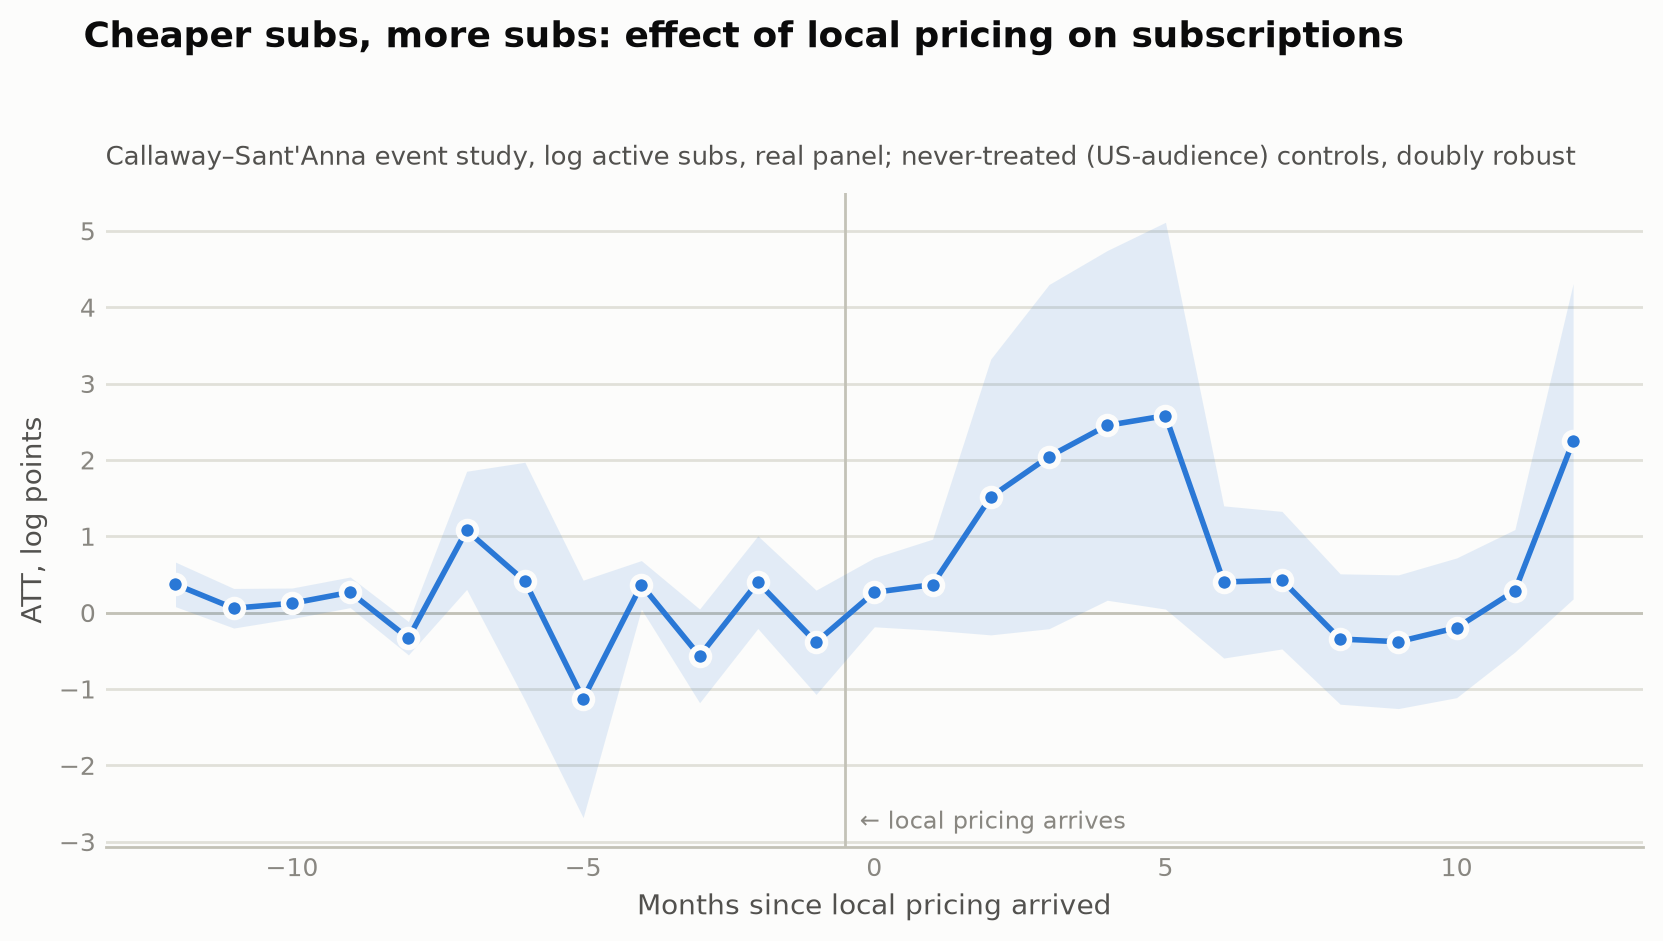

In [2]:
display(Image("../outputs/figures/event_study_log_subs.png", width=900))

## 2. The natural experiment in one picture

Real data: 29 treated channels (TR, MX, BR, ES, AR) vs 39 US-audience controls, monthly
subscriber counts by tier extracted from TwitchTracker's rendered charts (2020-01..2022-12,
attrition-censored).

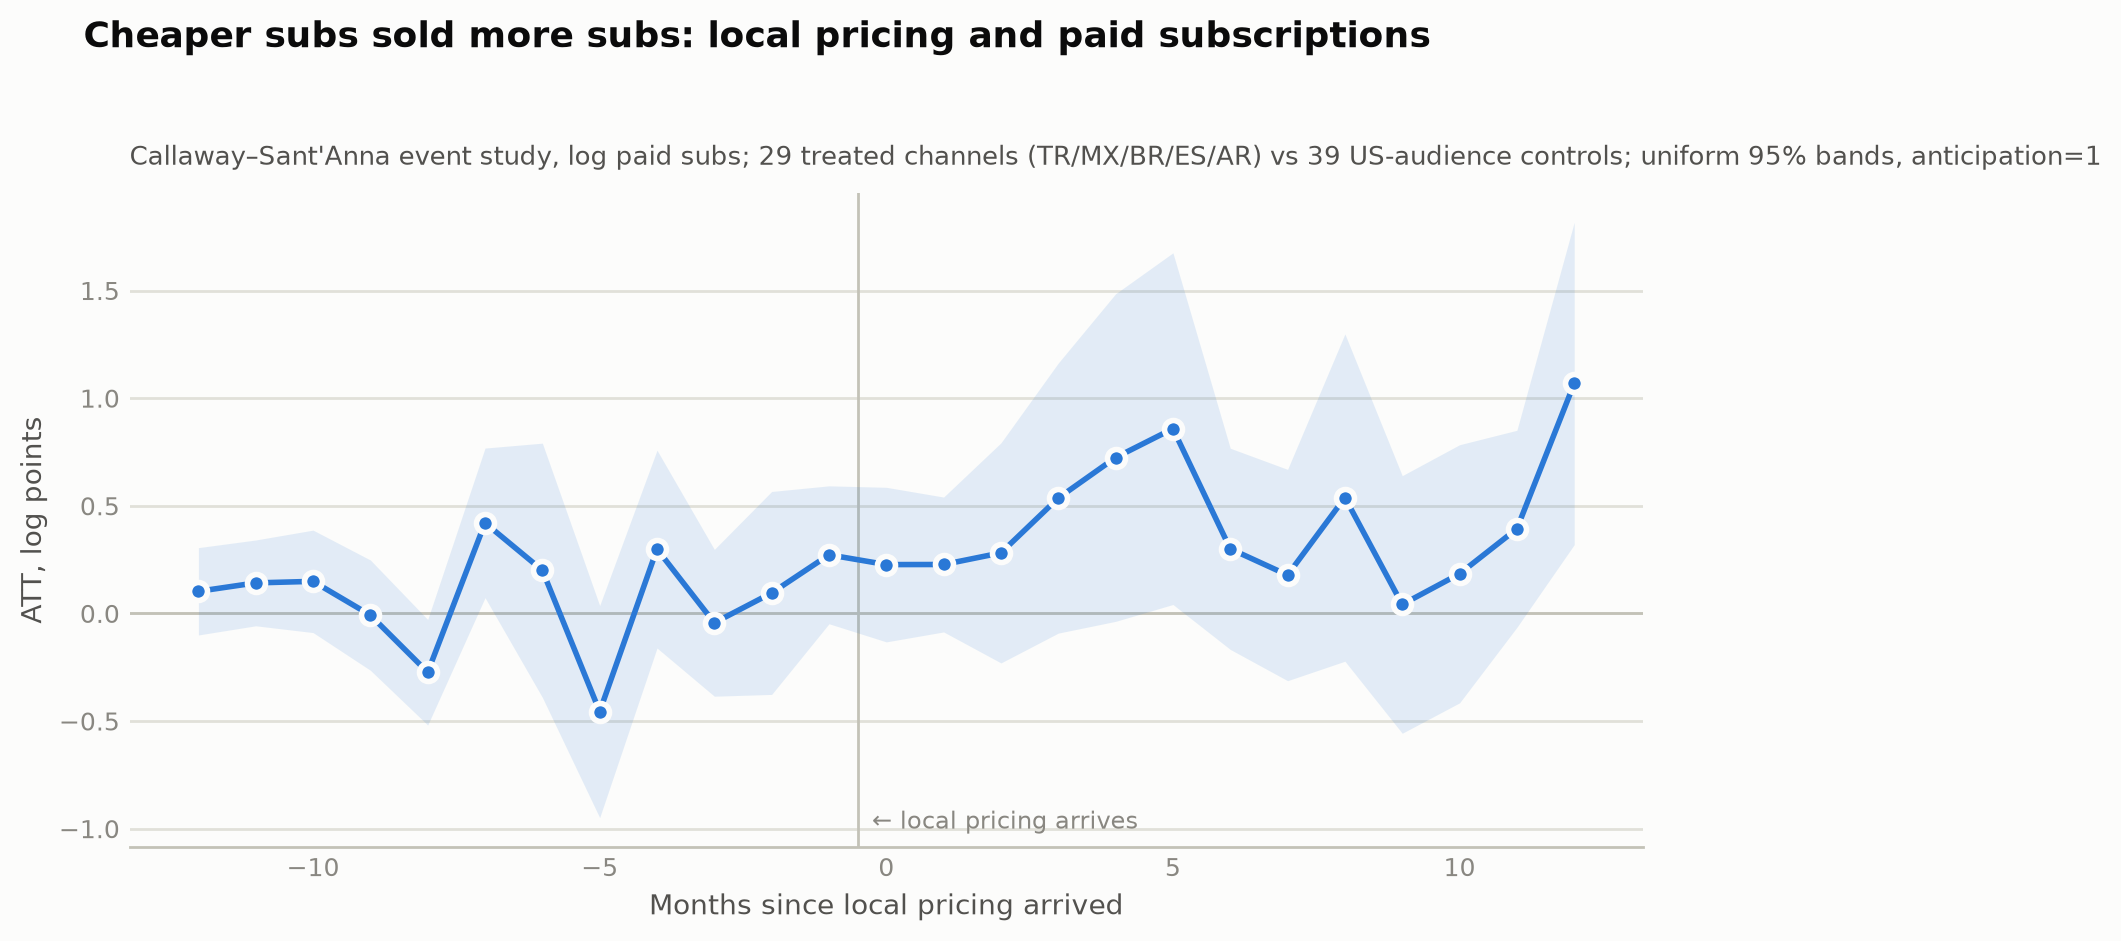

In [3]:
display(Image("../outputs/figures/real_event_study.png", width=900))

In [4]:
print(f"Overall ATT: {summary['cs_overall_att']:.3f} (se {summary['cs_overall_se']:.3f})")
print(f"Naive TWFE:  {summary['twfe_att']:.3f}  <- mixes clean and forbidden comparisons")
pd.DataFrame(summary["bacon_synthetic_by_type"])

Overall ATT: 0.561 (se 0.210)
Naive TWFE:  0.844  <- mixes clean and forbidden comparisons


,type,weight,avg_estimate
0,earlier_vs_later,0.077,0.423
1,later_vs_earlier(forbidden),0.075,0.115
2,treated_vs_never,0.849,0.433


## 3. Dose-response: the elasticity

Each country is one dose point: its mature-window ATT (6-12 months post) against its log price
change at rollout (curated price table, rollout-date FX).

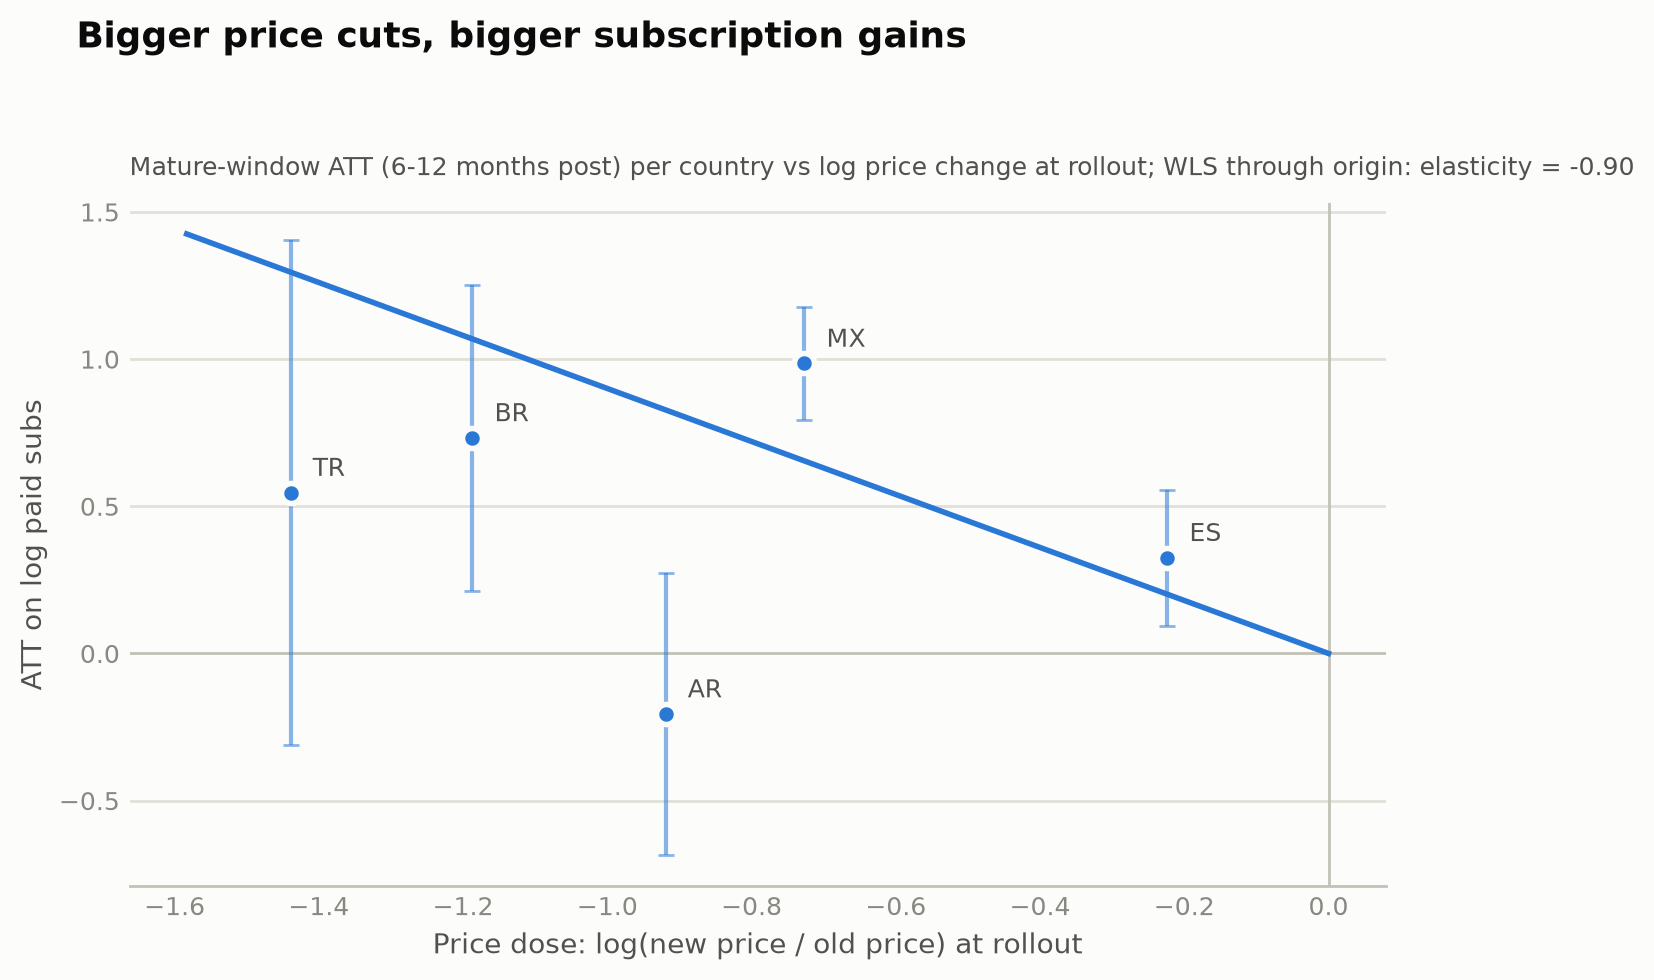

In [5]:
display(Image("../outputs/figures/dose_response.png", width=760))

In [6]:
print(f"elasticity (mature window): {summary['elasticity_mature']:.2f}")
print(f"  analytic se: {summary['elasticity_se_analytic']:.3f}")
print(f"  cluster-bootstrap 95% CI: {summary['elasticity_ci_boot']}")
pd.DataFrame(summary["dose_response"])

elasticity (mature window): -0.90
  analytic se: 0.098
  cluster-bootstrap 95% CI: [-1.3623334511946157, -0.33954222735227585]


,country,dlogp,att,se,n_channels
0,AR,-0.919,-0.206,0.245,4
1,BR,-1.187,0.733,0.265,7
2,ES,-0.224,0.325,0.118,12
3,MX,-0.727,0.985,0.098,2
4,TR,-1.439,0.547,0.438,4


## 4. Did we just measure a popularity boom? Placebos say no (mostly)

Prime subs are free (bundled with Amazon Prime), so a price cut should not move them.
The same design on log Prime subs is the sharpest falsification we have — plus fake
treatment dates on control channels and permutation inference.

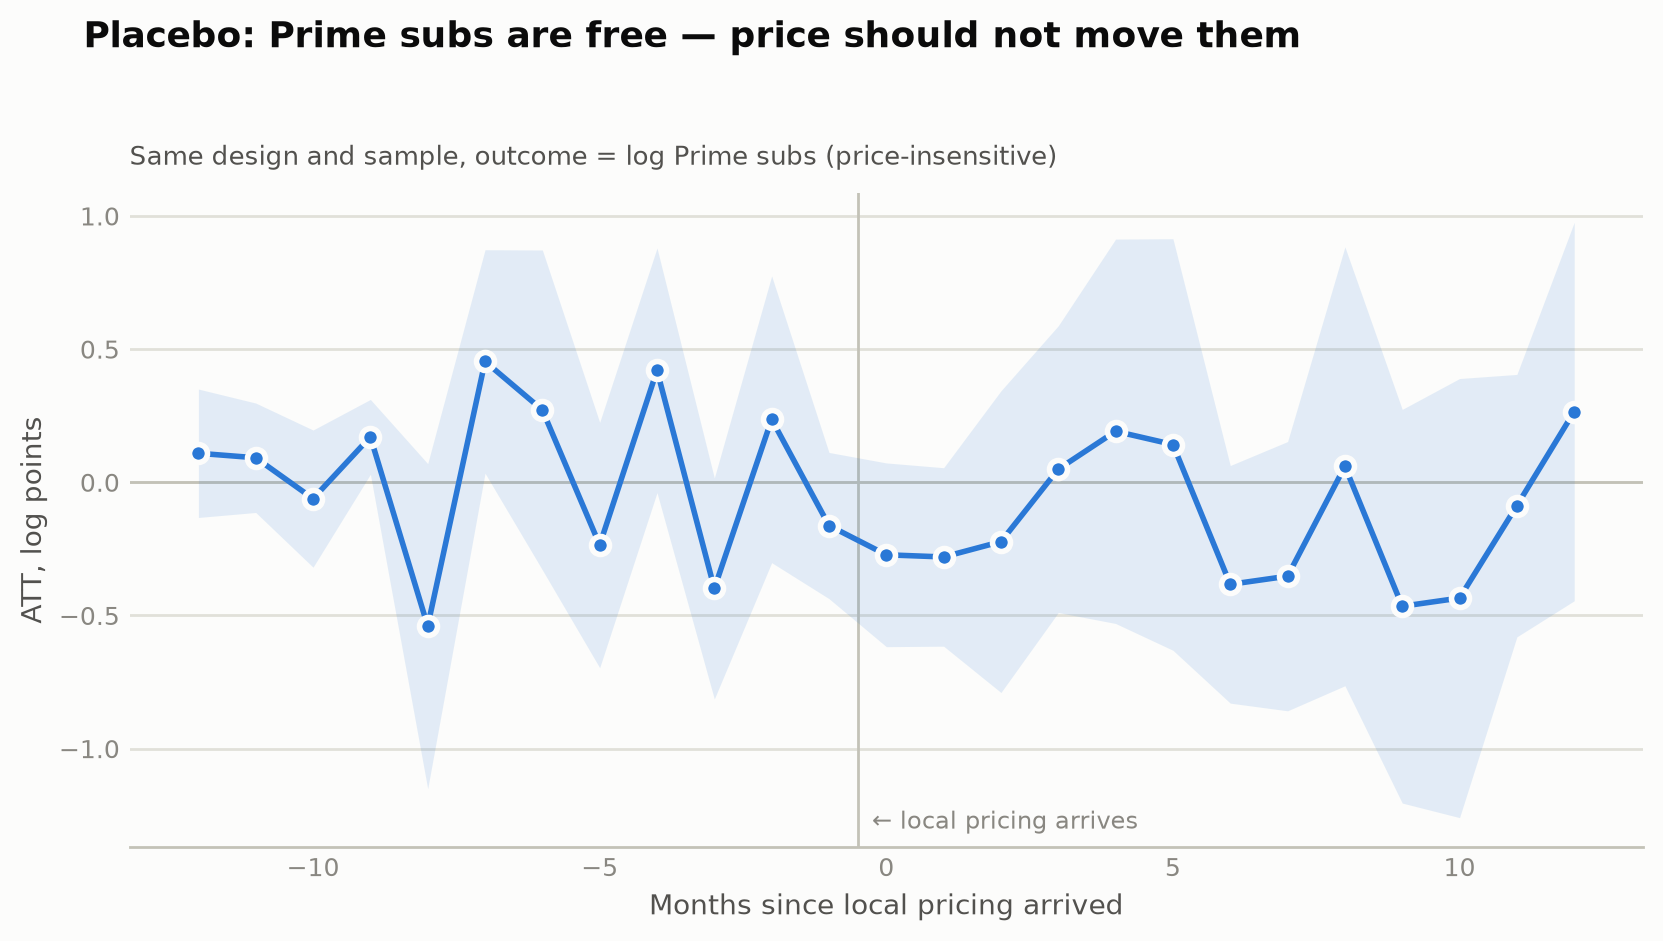

In [7]:
display(Image("../outputs/figures/placebo_prime_event_study.png", width=900))

In [8]:
print("Prime placebo ATT:", diagnostics["placebo_prime"])
print("Fake dates on controls:", diagnostics["placebo_fake_dates_on_controls"])
print("Permutation test:", {k: v for k, v in diagnostics["permutation_test"].items() if k != "perm_quantiles"})
print("Pre-trend joint test:", diagnostics["pretrends_joint_test"])
print("Linear-trend sensitivity:", diagnostics["linear_trend_sensitivity"])

Prime placebo ATT: {'att': -0.06689037972834577, 'se': 0.22160683337108172}
Fake dates on controls: {'att': -0.2325933596490063, 'se': 0.2735906935590827}
Permutation test: {'observed_att': 0.5608360946600607, 'n_permutations_effective': 200, 'p_value_two_sided': 0.005}
Pre-trend joint test: {'stat': 5.575865482338043, 'p_value': 0.3496986508073905, 'n_leads': 5, 'cov': 'diagonal-approx'}
Linear-trend sensitivity: {'slope': 0.030692844368929537, 'slope_se': 0.03278104275533198, 'post_avg_raw': 0.4274387478013827, 'post_avg_trend_adjusted': 0.21258883721887592}


## 5. Robustness battery

In [9]:
pd.read_csv("../outputs/estimates/robustness.csv")

,variant,att,se,note
0,baseline (never-treated controls),0.561,0.210,NaN
1,not-yet-treated controls,0.561,0.211,identification from timing only while g259 pen...
2,drop AR,0.647,0.209,NaN
3,drop BR,0.520,0.187,NaN
4,drop ES,0.630,0.283,NaN
5,drop MX,0.559,0.233,NaN
6,drop TR,0.503,0.248,NaN
7,language-only assignment (es pooled),0.552,0.226,ignores MX/AR vs ES timing differences - misas...
8,winsorized 1/99 within month,0.591,0.223,NaN
9,below-median pre-size,0.900,0.291,NaN


## 6. Honest limitations

- **Top-creator elasticity only.** TwitchTracker tracked few channels before May 2021; the treated
  side is ~29 large channels. This is not a platform-wide estimate.
- **Contaminated controls.** English-language channels have treated international viewers ->
  attenuation toward zero.
- **Gift subs inside paid counts.** Twitch reported 5x gifting in TR/MX after the cut; part of the
  measured response is gifting behavior.
- **Country assignment** for Spanish-language channels is curated and provisional.
- See README's threats-to-validity section for the full discussion.